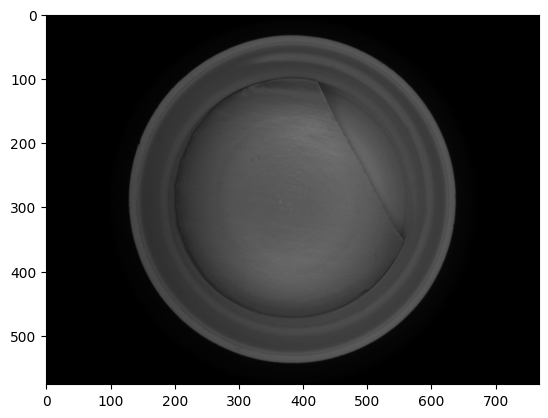

CAP OUTLINE - center: x=  384.5  y=  287.5  , radius=  255.1


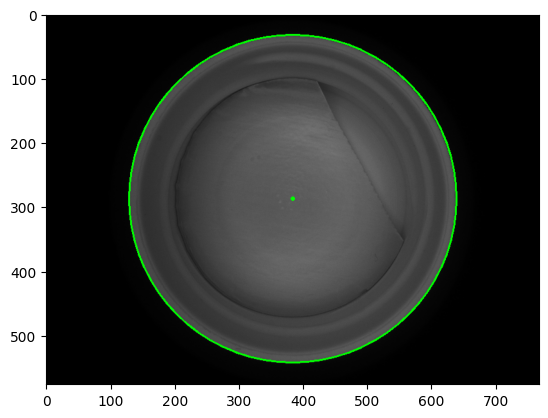

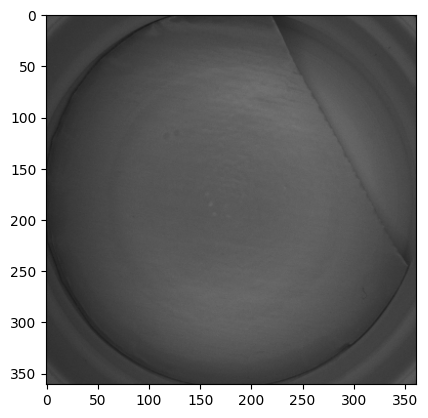

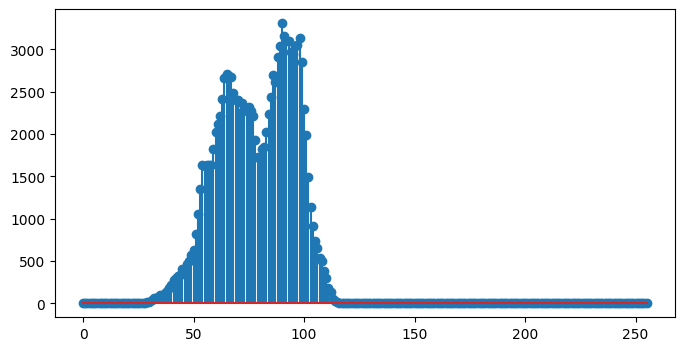

78.54803139939074
liner


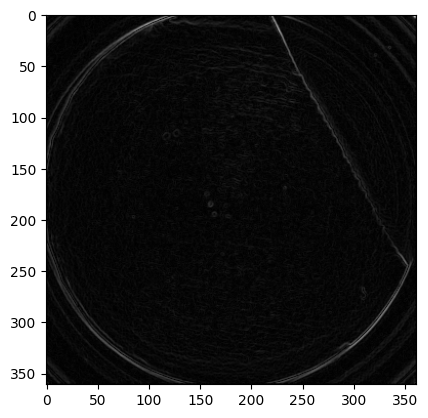

In [12]:
import numpy as np
import cv2
from matplotlib import pyplot as plt
import math

#### LOAD and show IMAGE
img_color = cv2.imread('cap-inspection-images/project_1_liner_inspection/d_18.bmp')
#img_color = cv2.imread('cap-inspection-images/project_1_liner_inspection/g_06.bmp')
img = cv2.cvtColor(img_color,cv2.COLOR_BGR2GRAY)
plt.figure()
plt.imshow(img,cmap='gray',vmin=0,vmax=255)
plt.show()

#### histogram 
hist, bins = np.histogram(img.flatten(), 256, [0,256])
'''
plt.figure(2,figsize=[8,4])
plt.stem(hist)
plt.show()
'''
######## TASK 1.1:  Outline the cap by generating a circle that fits the cap mouth #########
#img_blur = cv2.GaussianBlur(img,(7,7),0)
img_blur = cv2.bilateralFilter(img,7,50,75)
circles = cv2.HoughCircles(img_blur,cv2.HOUGH_GRADIENT, 1, 45,param1=70,param2=70) # ok per trovare esterno dei tappi
# param1: threshold della differenza del gradiente (+alto = colori + diversi) (per il canny "integrato") - + alta mi trova solo il cerchio esterno
# param2 : perfezione del cerchio
#print(circles, circles.shape)
center = (circles[0][0][0],circles[0][0][1])
radius = circles[0][0][2]
'''for c in circles[0,:] : 
    cv2.circle(img_color,(int(c[0]),int(c[1])),int(c[2]),color=(0, 255, 0),thickness=2)
    cv2.circle(img_color,(int(c[0]),int(c[1])),int(2),color=(0, 255, 0),thickness=2)
    print("center: x= ", c[0]," y= ",c[1]," - radius= ",c[2])
'''

cv2.circle(img_color,(int(center[0]),int(center[1])),int(radius),color=(0, 255, 0),thickness=2)
cv2.circle(img_color,(int(center[0]),int(center[1])),int(2),color=(0, 255, 0),thickness=2)
print("CAP OUTLINE - center: x= ", center[0]," y= ",center[1]," , radius= ",radius )
plt.imshow(img_color)
plt.show()

#### ROI OF INSIDE THE CAP
offset = ((radius/math.sqrt(2))+radius)/2 # half way
offset = (radius/math.sqrt(2)) # inscritta
#offset = (radius*0.8) # accazzodicane ma funziona
x_max=math.ceil(center[0]+offset)
x_min=math.floor(center[0]-offset)
y_max=math.ceil(center[1]+offset)
y_min=math.floor(center[1]-offset)  



img_roi=img[y_min:y_max,x_min:x_max]
img_roi_show=img_roi.copy()
plt.figure()
plt.imshow(img_roi,cmap='gray',vmin=0,vmax=255)
plt.show()
hist_roi, bins_roi = np.histogram(img_roi.flatten(), 256, [0,256])

plt.figure(2,figsize=[8,4])
plt.stem(hist_roi)
plt.show()


###########################LINER O NO LINER CON AVERAGE LIGHTNESS
avg=cv2.mean(img_roi)[0]
print(avg)              ########## LINER: intorno a 70 - NO LINER: intorno a 90 - "threshold"=80 
if avg>80 : 
    print("NO LINER")
else :     
    ############################TROVARE IL DIFETTO "INSPECTING THE MAGNITUDE OF THE GADIENT"
    print("liner")
    img_roi_sobelx = cv2.Sobel(img_roi,cv2.CV_64F,1,0,ksize=3)
    img_roi_sobely = cv2.Sobel(img_roi,cv2.CV_64F,0,1,ksize=3)
    img_roi_gradient_magnitude = cv2.convertScaleAbs(cv2.magnitude(img_roi_sobelx, img_roi_sobely))
    plt.figure()
    plt.imshow(img_roi_gradient_magnitude,cmap='gray',vmin=0,vmax=255)
    plt.show()



